## Observing the CMB

Instrument(1 array)
├ arrays:
│             n     FOV baseline                        bands polarized
│  array1  1048  41.84’      0 m  [act/pa5/f090,act/pa5/f150]      True
│ 
└ bands:
              name   center   width    η         NEP      NET_RJ         NET_CMB    FWHM
   0  act/pa5/f090   90 GHz  20 GHz  0.5  1.469 aW√s  10 uK_RJ√s  12.29 uK_CMB√s  1.458’
   1  act/pa5/f150  150 GHz  30 GHz  0.5  2.204 aW√s  10 uK_RJ√s  17.33 uK_CMB√s  52.49”


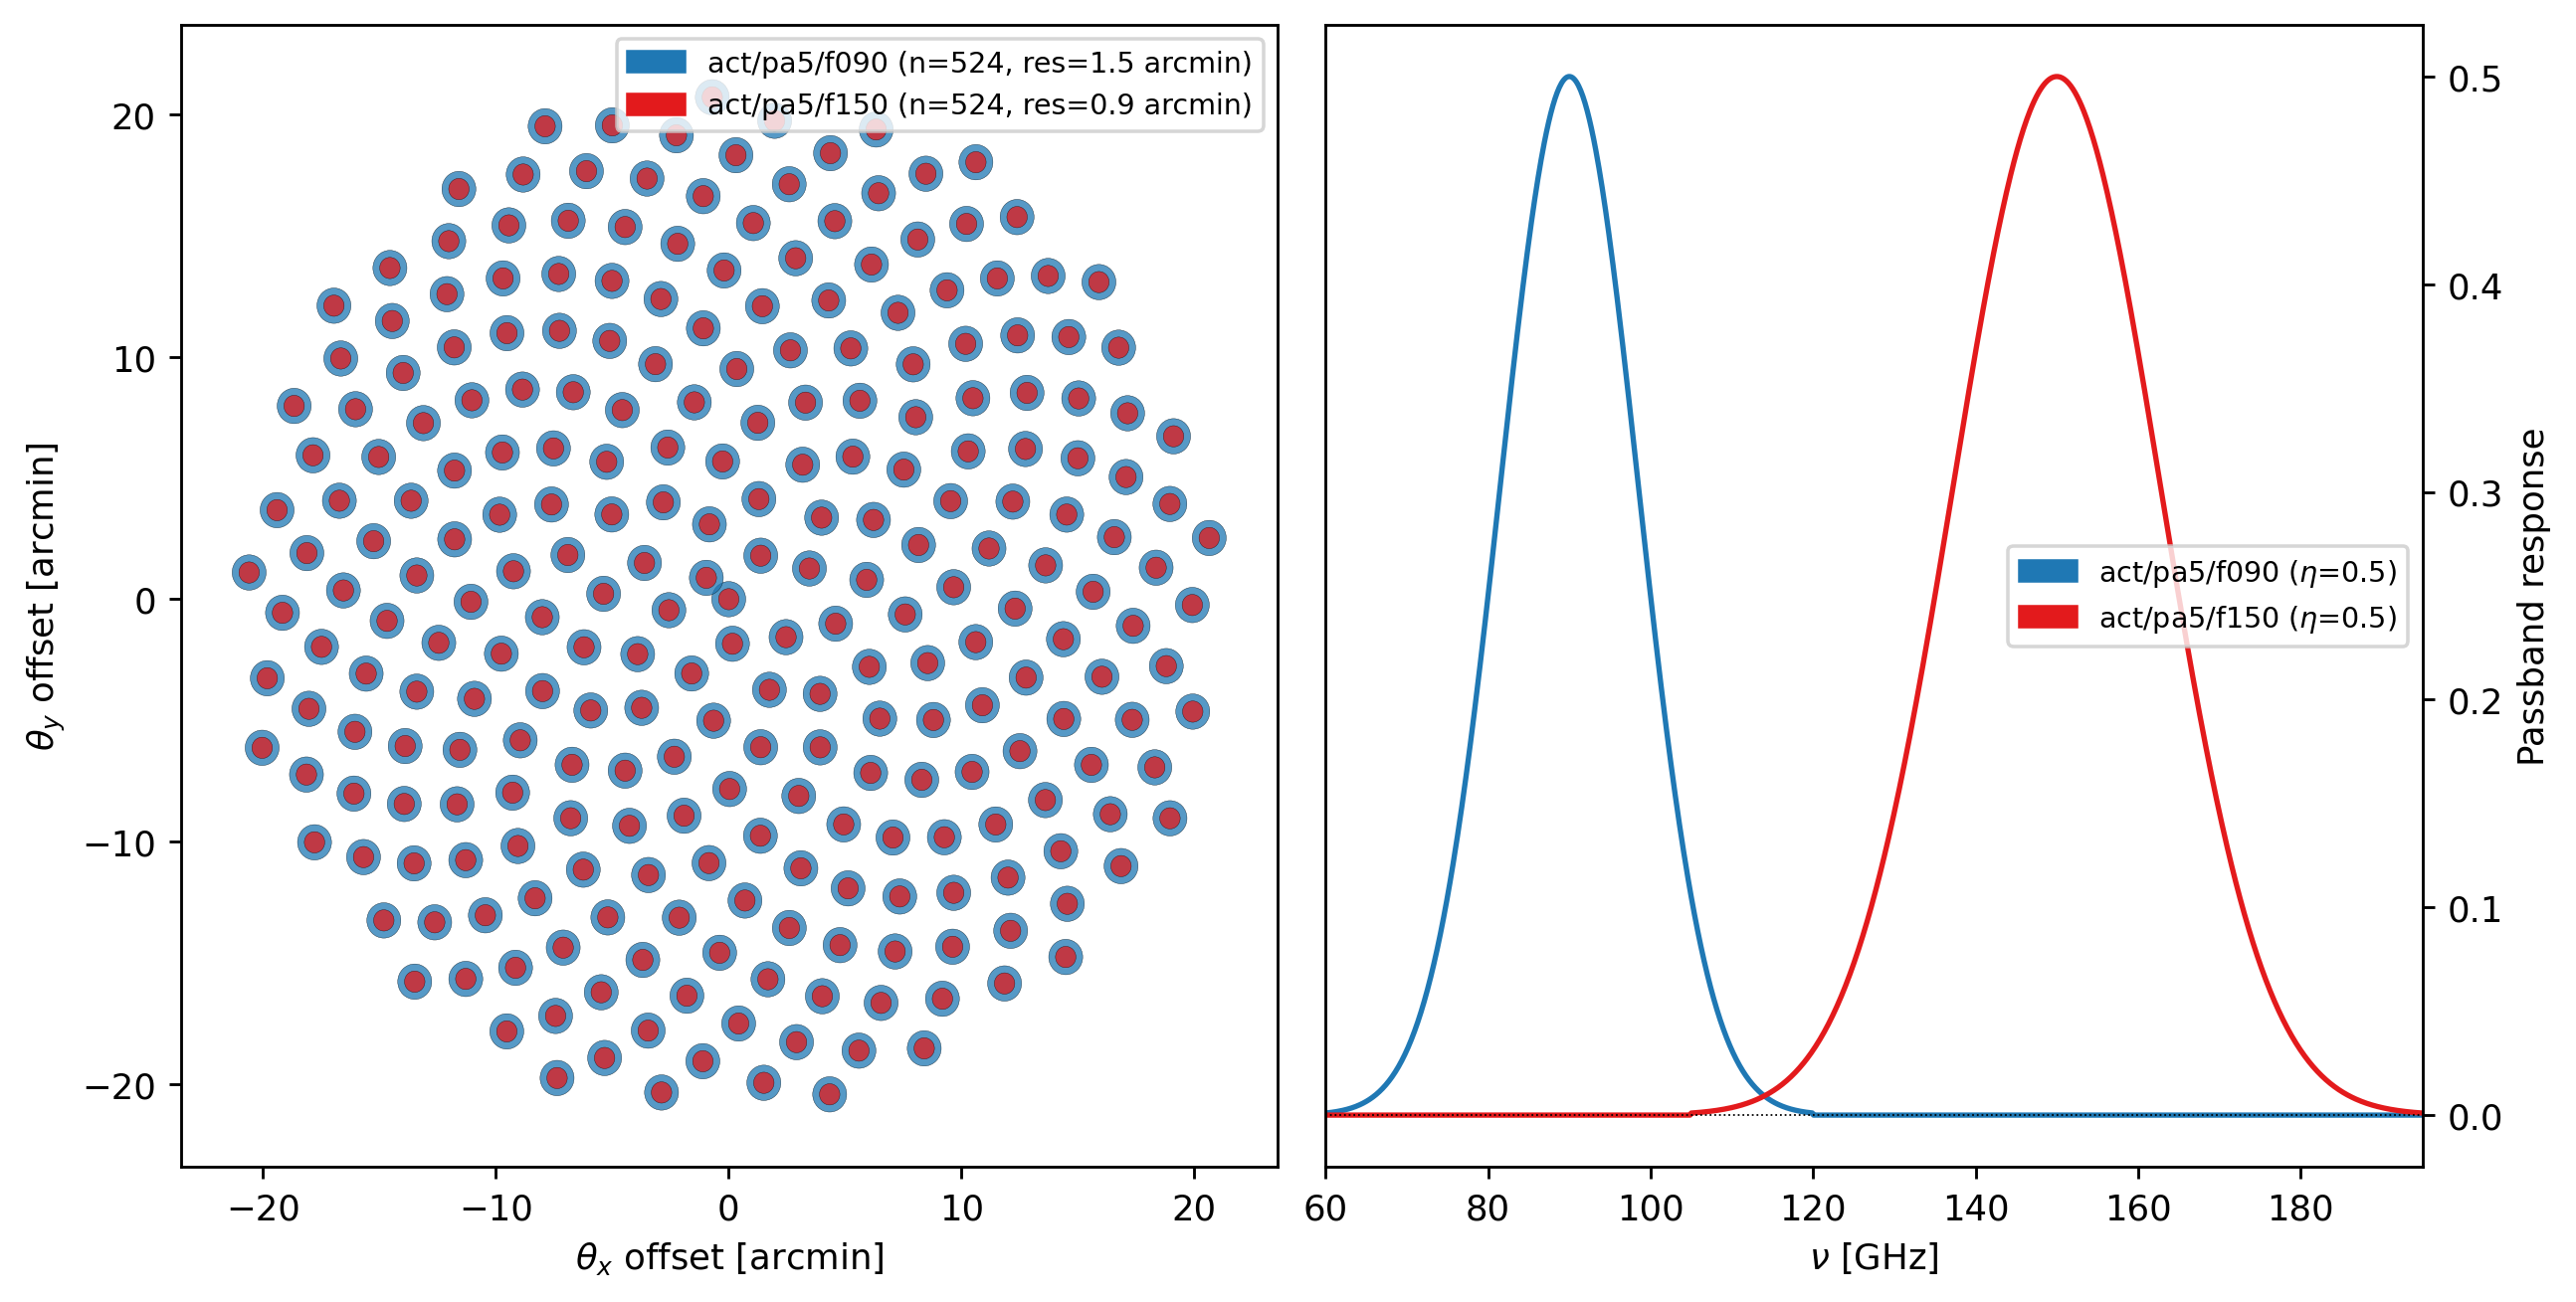

In [1]:
import maria
from maria.band import get_band

f090 = get_band("act/pa5/f090")
f150 = get_band("act/pa5/f150")


f090.NET_RJ = 10e-6
f150.NET_RJ = 10e-6

f090.knee = 1e1
f150.knee = 1e1

array = {"field_of_view": 0.7,
         "beam_spacing": 1.5,
         "primary_size": 10,
         "packing": "sunflower",
         "shape": "circle",
         "polarized": True,
         "bands": [f090, f150]}

instrument = maria.get_instrument(array=array)

print(instrument)
instrument.plot()

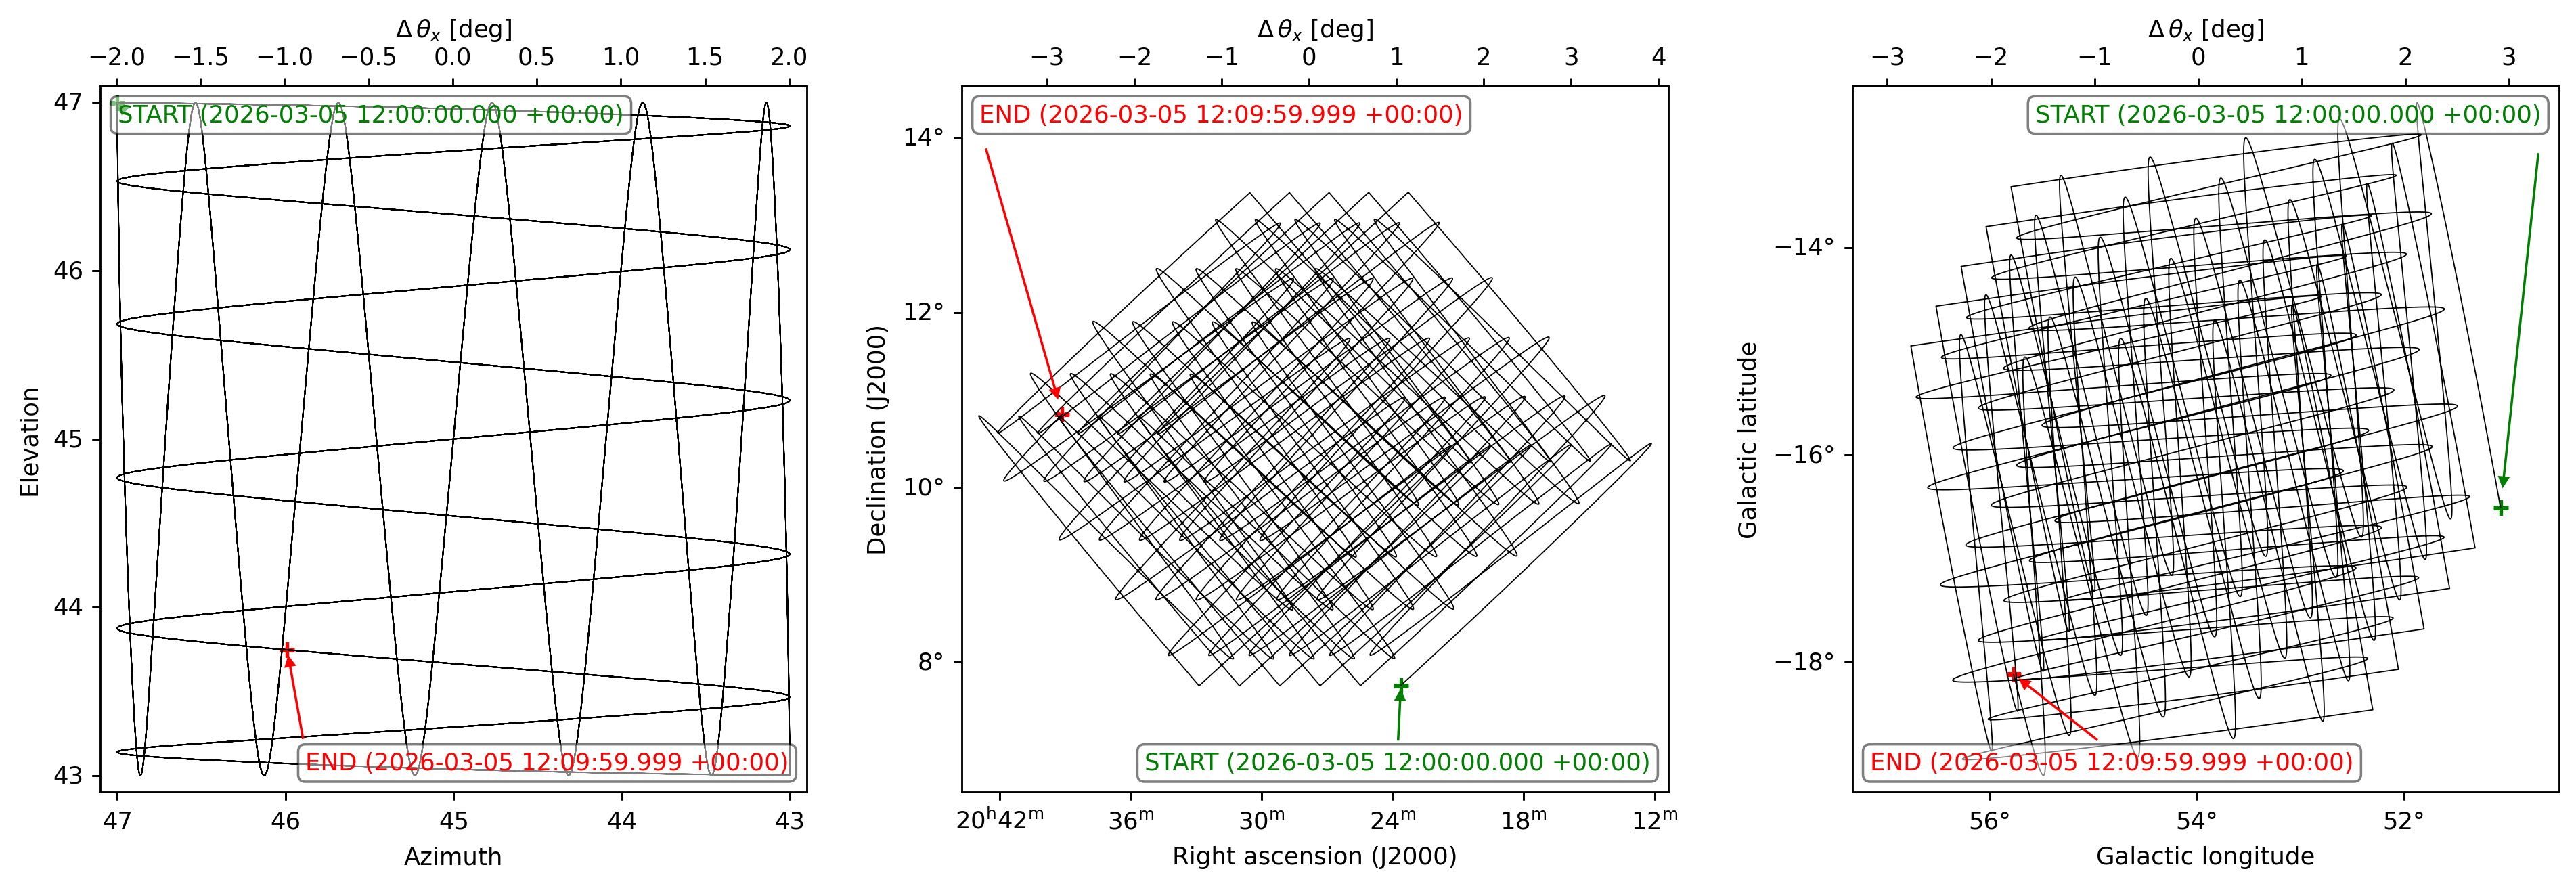

In [2]:
import numpy as np
from maria import Plan
from maria.plan import *

plan = Plan.generate(duration=600, 
                     sample_rate=20, 
                     start_time="2026-03-05T12:00:00",
                     scan_center=(45, 45), 
                     scan_pattern="raster",
                     scan_options={"x_throw": 2, "y_throw": 2, "speed": 1e0},
                     frame="az/el", 
                     site="cerro_toco")

plan.plot(frames=["az/el", "ra/dec", "glon/glat"])

In [3]:
sim = maria.Simulation(
    instrument=instrument,
    plans=[plan],
    site="cerro_toco",
    cmb="generate",
    cmb_kwargs={"nside": 2048},
)

print(sim)

Generating CMB (nside=2048):   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-28 04:05:47.464 INFO: Fetching https://github.com/thomaswmorris/maria-data/raw/master/cmb/spectra/lensed.csv


Downloading:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

Downloading: |          | 2.87M/? [00:00<00:00, 28.5MB/s]

Downloading: |          | 3.72M/? [00:00<00:00, 32.7MB/s]

Generating CMB (nside=2048): 100%|██████████| 1/1 [00:55<00:00, 55.41s/it]

Generating CMB (nside=2048): 100%|██████████| 1/1 [00:55<00:00, 55.41s/it]

Simulation
├ Instrument(1 array)
│ ├ arrays:
│ │             n     FOV baseline                        bands polarized
│ │  array1  1048  41.84’      0 m  [act/pa5/f090,act/pa5/f150]      True
│ │ 
│ └ bands:
│               name   center   width    η         NEP      NET_RJ         NET_CMB    FWHM
│    0  act/pa5/f090   90 GHz  20 GHz  0.5  1.469 aW√s  10 uK_RJ√s  12.29 uK_CMB√s  1.458’
│    1  act/pa5/f150  150 GHz  30 GHz  0.5  2.204 aW√s  10 uK_RJ√s  17.33 uK_CMB√s  52.49”
├ Site:
│   region: chajnantor
│   timezone: America/Santiago
│   location:
│     longitude: 67°47’16.08” W
│     latitude:  22°57’30.96” S
│     altitude: 5.19 km
│   seasonal: True
│   diurnal: True
├ PlanList(1 plans, 600 s):
│                            start_time duration     target(az,el)
│ chunk                                                           
│ 0      2026-03-05 12:00:00.000 +00:00    600 s  (45.01°, 45.04°)
└ CMB:
    data(3, 1, 1, 50331648):
      min: -5.911e-04
      max: 5.725e-04
      uni

2026-05-28 04:06:42.660 INFO: Simulating observation 1 of 1


Sampling CMB:   0%|          | 0/2 [00:00<?, ?it/s]

Sampling CMB:   0%|          | 0/2 [00:00<?, ?it/s, band=act/pa5/f090]

Sampling CMB:   0%|          | 0/2 [00:00<?, ?it/s, band=act/pa5/f090, stokes=I]

Sampling CMB:   0%|          | 0/2 [00:00<?, ?it/s, band=act/pa5/f090, stokes=Q]

...

Generating noise:  50%|█████     | 1/2 [00:00<00:00,  1.51it/s, band=act/pa5/f090]

Generating noise:  50%|█████     | 1/2 [00:00<00:00,  1.51it/s, band=act/pa5/f150]

Generating noise: 100%|██████████| 2/2 [00:01<00:00,  2.10it/s, band=act/pa5/f150]

Generating noise: 100%|██████████| 2/2 [00:01<00:00,  1.98it/s, band=act/pa5/f150]

2026-05-28 04:06:46.367 INFO: Simulated observation 1 of 1 in 3.7 s


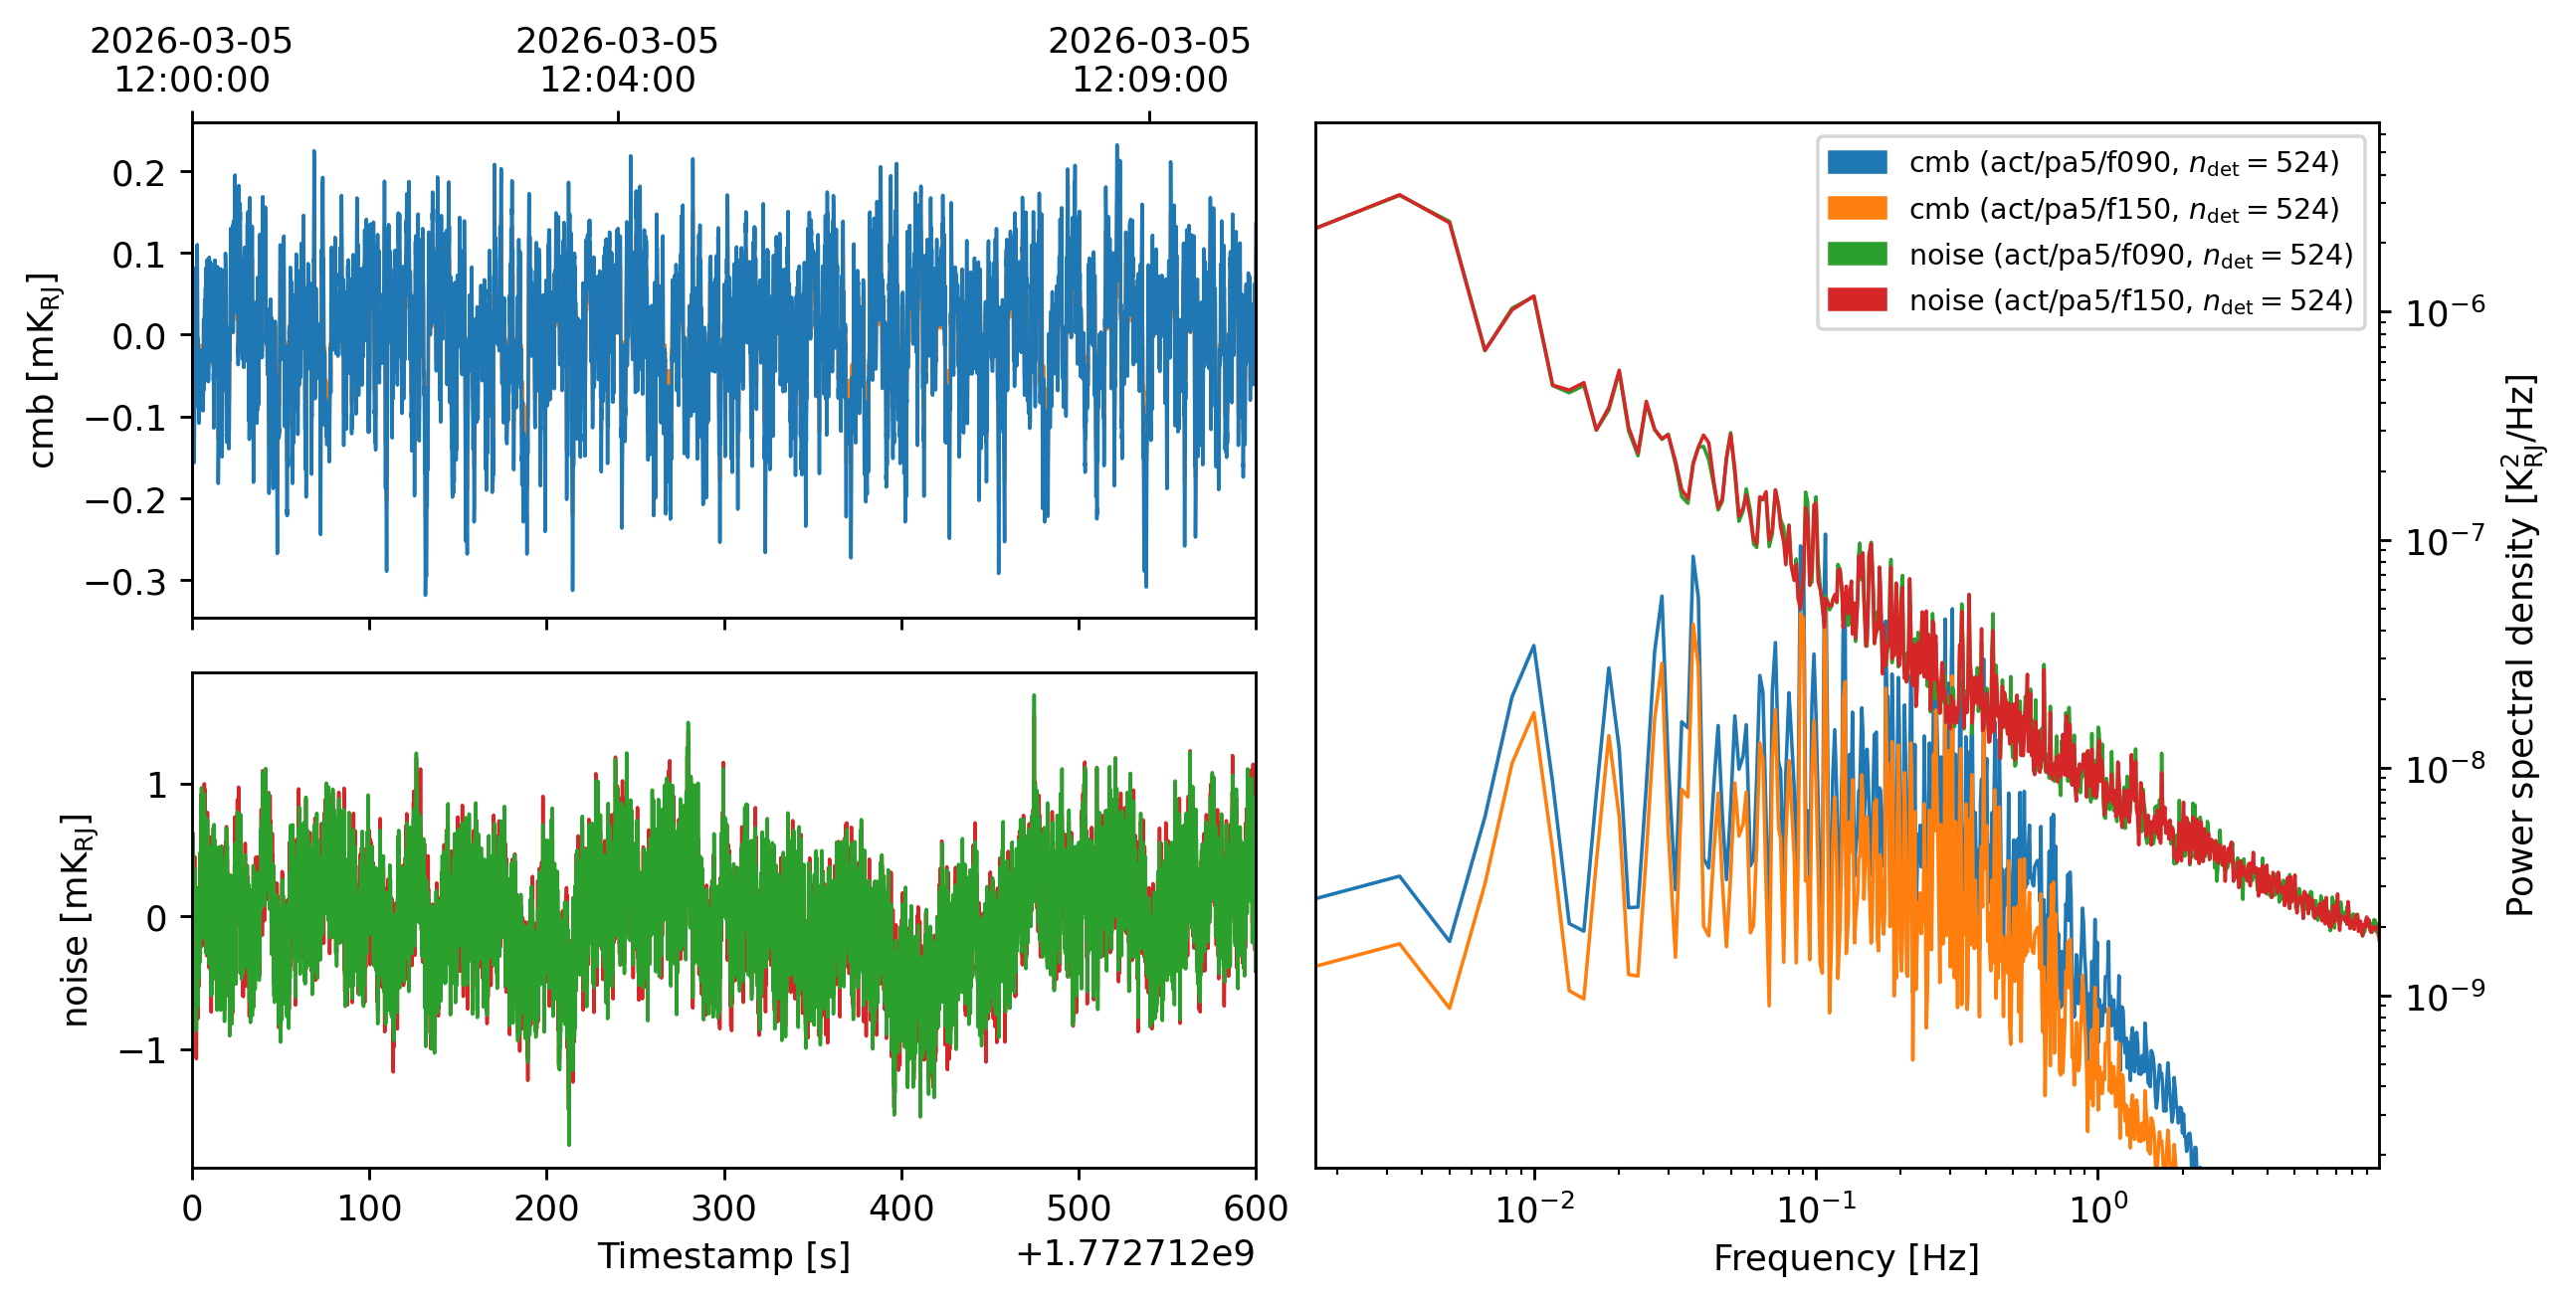

In [4]:
tods = sim.run()
tods[0].plot()

In [5]:
from maria.mappers.ml_mapper import *

ml_mapper = MaximumLikelihoodMapper(tods=tods,
                                    frame="ra/dec",
                                    resolution=2 / 60,  # degrees
                                    tod_preprocessing={
                                        "remove_spline": {"knot_spacing": 60, "remove_el_gradient_order": 3},
                                    },
                                    bilinear=False,
                                    k=0)

2026-05-28 04:06:51.053 INFO: Inferring center {'ra': '20ʰ27ᵐ50.01ˢ', 'dec': '10°31’5.27”'} for mapper


2026-05-28 04:06:51.061 INFO: Inferring mapper width 8.468° for mapper from observation patch


2026-05-28 04:06:51.061 INFO: Inferring mapper height 8.468° to match supplied width


2026-05-28 04:06:51.063 INFO: Inferring stokes parameters 'IQU' for mapper from detector sensitivities


Preprocessing TODs:   0%|          | 0/1 [00:00<?, ?it/s]

Preprocessing TODs: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]

Preprocessing TODs: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]

Computing pointing matrices:   0%|          | 0/1 [00:00<?, ?it/s]

Computing pointing matrices: 100%|██████████| 1/1 [00:05<00:00,  5.15s/it]

Computing pointing matrices: 100%|██████████| 1/1 [00:05<00:00,  5.15s/it]

ProjectionMap:
  data(3, 2, 1, 254, 254):
    min: -3.301e-04
    max: 1.866e-04
    units: K_RJ
    quantity: rayleigh_jeans_temperature
  stokes(3):
    components: IQU
  nu(2):
    values: [ 90. 150.] GHz
  t(1):
    values: [1.7727123e+09] s
  eta(254):
    height: 8.433°
    res: -2’
  xi(254): 
    width: 8.433°
    res: 2’
  frame: ra/dec
  center:
    ra: 20ʰ27ᵐ50.01ˢ
    dec: 10°31’5.27”
  beam(maj, min, psi): ragged
  memory: 3.097 MB


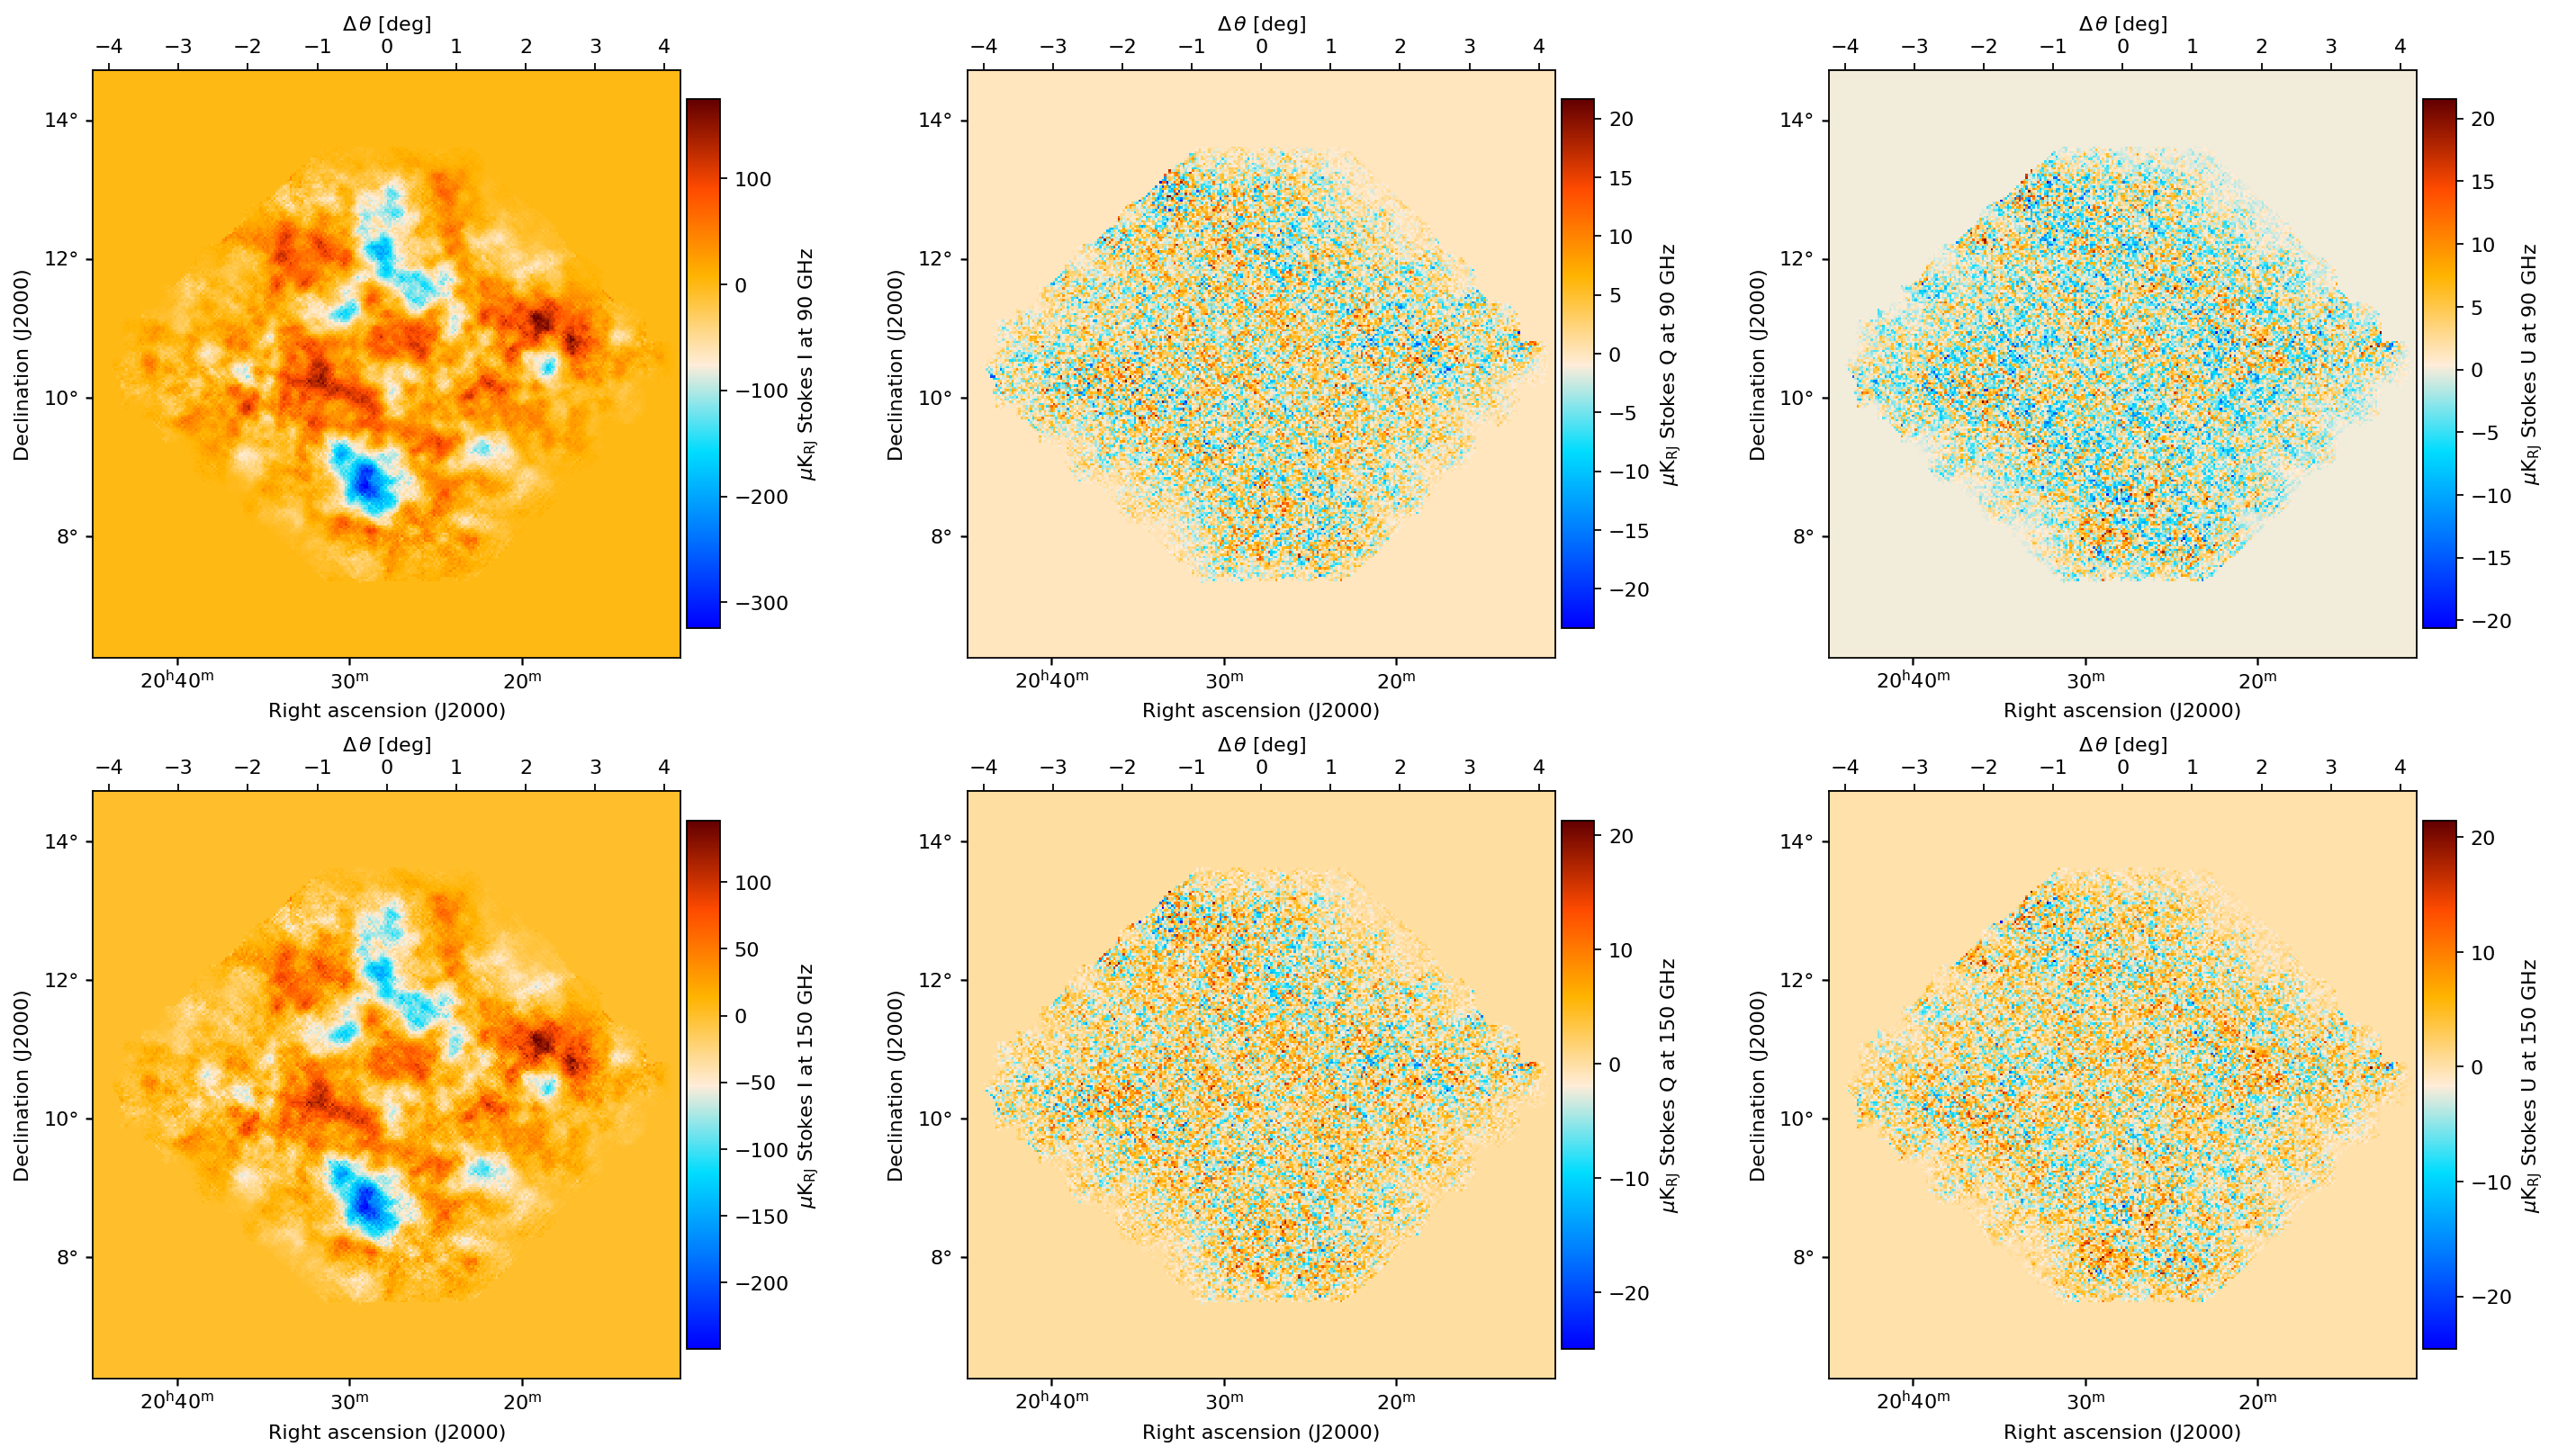

In [6]:
print(ml_mapper.map)
ml_mapper.map.plot(slices=dict(stokes=["I", "Q", "U"], nu=[[0], [1]]), 
                   cmap="cmb", contrast=1e-4)